# `src/api` smoke tests

One cell per public function. The first cell touching the API pays the full cost (~1s); the rest are instant cache hits.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt

from src.api import (
    get_account_risk, explain_account, top_risk_accounts,
    feature_importance, portfolio_summary, probability_distribution,
)

## `portfolio_summary()`

In [2]:
pprint(portfolio_summary())

{'avg_probability': 0.015049509704113007,
 'model_metrics': {'average_precision': 0.8805,
                   'f1': 0.6982,
                   'f2': 0.7973,
                   'n_features': 13,
                   'n_test_positives': 109,
                   'n_test_rows': 1000,
                   'precision': 0.5783,
                   'recall': 0.8807,
                   'trained_at': '2026-05-04T02:09:50+00:00'},
 'n_active': 4454,
 'n_churned': 546,
 'n_high_risk': 129,
 'pct_high_risk': 0.028962730130220028,
 'threshold': 0.1,
 'total_accounts': 5000}


/Users/vidyutveedgav/churnguard-analytics/src/preprocessing.py:294: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pp_df[output_col] = (pp_df[source_col] >= threshold).astype(int)
/Users/vidyutveedgav/churnguard-analytics/src/preprocessing.py:316: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pp_df[new_col] = oh[new_col].values
/Users/vidyutveedgav/churnguard-analytics/src/preprocessing.py:316: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perf

## `top_risk_accounts(n=5)`

In [3]:
pd.DataFrame(top_risk_accounts(n=5))

,account_id,probability,predicted_label
0,ACC003736,0.544408,churn
1,ACC002526,0.461184,churn
2,ACC002636,0.459222,churn
3,ACC001728,0.404806,churn
4,ACC004480,0.396774,churn


## `feature_importance(top_k=10)`

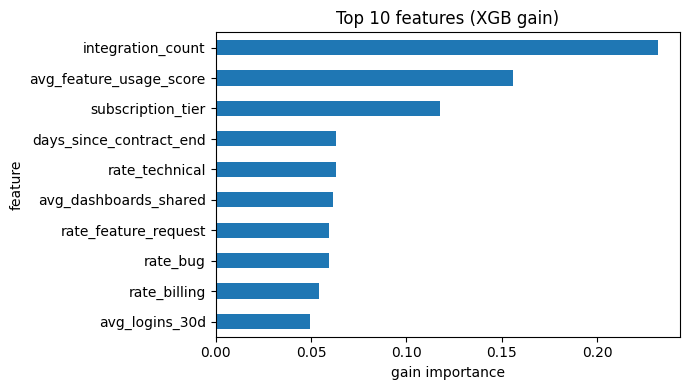

,rank,feature,importance
0,1,integration_count,0.231659
1,2,avg_feature_usage_score,0.155978
2,3,subscription_tier,0.117736
3,4,days_since_contract_end,0.063220
4,5,rate_technical,0.063131
5,6,avg_dashboards_shared,0.061620
6,7,rate_feature_request,0.059348
7,8,rate_bug,0.059167
8,9,rate_billing,0.054229
9,10,avg_logins_30d,0.049522


In [4]:
fi = pd.DataFrame(feature_importance(top_k=10))
ax = fi.set_index('feature')['importance'][::-1].plot.barh(figsize=(7, 4))
ax.set_xlabel('gain importance'); ax.set_title('Top 10 features (XGB gain)')
plt.tight_layout(); plt.show()
fi

## `probability_distribution(bins=20)`

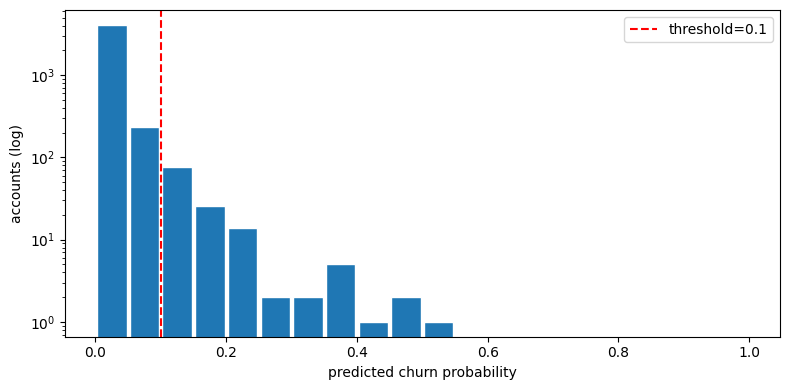

In [5]:
d = probability_distribution(bins=20)
centers = [(d['bin_edges'][i] + d['bin_edges'][i+1]) / 2 for i in range(len(d['counts']))]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(centers, d['counts'], width=0.045, edgecolor='white')
ax.axvline(d['threshold'], color='red', linestyle='--', label=f"threshold={d['threshold']}")
ax.set_yscale('log')
ax.set_xlabel('predicted churn probability'); ax.set_ylabel('accounts (log)'); ax.legend()
plt.tight_layout(); plt.show()

## `get_account_risk(account_id)`

In [6]:
acct = top_risk_accounts(1)[0]['account_id']
pprint(get_account_risk(acct))

{'account_id': 'ACC003736',
 'actual_status': 'active',
 'predicted_label': 'churn',
 'probability': 0.5444080829620361,
 'threshold': 0.1}


In [7]:
try:
    get_account_risk('ACC999999')
except KeyError as ex:
    print('expected:', ex)

expected: "account_id 'ACC999999' not in scoring frame"


## `explain_account(account_id, top_k=3)`

In [8]:
e = explain_account(acct, top_k=3)
print(f"{e['account_id']}  prob={e['probability']:.4f}  label={e['predicted_label']}  base={e['base_value']:.4f}")
print('\ndrivers:');    pprint(e['top_drivers'])
print('\nprotectors:'); pprint(e['top_protectors'])

ACC003736  prob=0.5444  label=churn  base=-2.2192

drivers:
[{'contribution_logodds': 1.4432706832885742,
  'direction': 'increases_risk',
  'feature': 'integration_count',
  'value': 1},
 {'contribution_logodds': 0.6374503374099731,
  'direction': 'increases_risk',
  'feature': 'rate_bug',
  'value': 0.0},
 {'contribution_logodds': 0.5832865238189697,
  'direction': 'increases_risk',
  'feature': 'rate_billing',
  'value': 0.0}]

protectors:
[{'contribution_logodds': -0.9828009605407715,
  'direction': 'decreases_risk',
  'feature': 'days_since_contract_end',
  'value': -202},
 {'contribution_logodds': -0.16705700755119324,
  'direction': 'decreases_risk',
  'feature': 'total_logins_90d',
  'value': 29},
 {'contribution_logodds': -0.15944541990756989,
  'direction': 'decreases_risk',
  'feature': 'avg_feature_usage_score',
  'value': 38.889278500944464}]


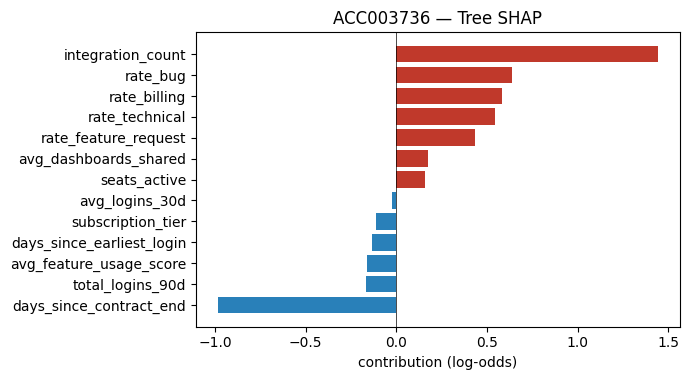

In [9]:
e_full = explain_account(acct, top_k=99)
rows = [(d['feature'], d['contribution_logodds']) for d in (*e_full['top_drivers'], *e_full['top_protectors'])]
rows.sort(key=lambda r: r[1])
labels, vals = zip(*rows)
colors = ['#c0392b' if v > 0 else '#2980b9' for v in vals]
fig, ax = plt.subplots(figsize=(7, max(3, 0.3 * len(labels))))
ax.barh(labels, vals, color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('contribution (log-odds)'); ax.set_title(f'{acct} — Tree SHAP')
plt.tight_layout(); plt.show()

Sanity: `base + Σ contributions == logit(probability)`.

In [10]:
from scipy.special import logit
margin = e_full['base_value'] + sum(d['contribution_logodds'] for d in (*e_full['top_drivers'], *e_full['top_protectors']))
print(f'reconstructed margin: {margin:.6f}')
print(f'logit(probability):   {logit(e_full["probability"]):.6f}')
print(f'abs diff:             {abs(margin - logit(e_full["probability"])):.2e}')

reconstructed margin: 0.178101
logit(probability):   0.178102
abs diff:             5.24e-07
